# [9665] Word Cloud
Data file:
* https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9665/main/data/GameOfThrones.csv

In [1]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 02/09/25 13:39:48


### Import libraries

In [2]:
! pip install wikipedia

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11679 sha256=b97a4f0525db0cb9f30c1089b2f249b24ca5ee77fd522010e7bb61bf00fc17e0
  Stored in directory: /root/.cache/pip/wheels/8f/ab/cb/45ccc40522d3a1c41e1d2ad53b8f33a62f394011ec38cd71c6
Successfully built wikipedia


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import wikipedia

## Example 1

### Load data

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9665/main/data/GameOfThrones.csv',
                 index_col='No. of Episode (Overall)')
df.shape

(73, 18)

In [5]:
df.head()

,Season,No. of Episode (Season),Title of the Episode,Running Time (Minutes),Directed by,Written by,Original Air Date,U.S. Viewers (Millions),Music by,Cinematography by,Editing by,IMDb Rating,Rotten Tomatoes Rating (Percentage),Metacritic Ratings,Ordered,Filming Duration,Novel(s) Adapted,Synopsis
No. of Episode (Overall),,,,,,,,,,,,,,,,,,
1,1,1,Winter Is Coming,61,Tim Van Patten,"David Benioff, D. B. Weiss",17-Apr-2011,2.22,Ramin Djawadi,Alik Sakharov,Oral Norrie Ottey,8.9,100,9.1,"March 2, 2010",Second half of 2010,A Game of Thrones,"North of the Seven Kingdoms of Westeros, Night..."
2,1,2,The Kingsroad,55,Tim Van Patten,"David Benioff, D. B. Weiss",24-Apr-2011,2.20,Ramin Djawadi,Alik Sakharov,Oral Norrie Ottey,8.6,100,8.9,"March 2, 2010",Second half of 2010,A Game of Thrones,"Ned, the new Hand of the King, travels to King..."
3,1,3,Lord Snow,57,Brian Kirk,"David Benioff, D. B. Weiss",1-May-2011,2.44,Ramin Djawadi,Marco Pontecorvo,Frances Parker,8.5,81,8.7,"March 2, 2010",Second half of 2010,A Game of Thrones,Ned attends the King's Small Council and learn...
4,1,4,"Cripples, Bastards, and Broken Things",55,Brian Kirk,Bryan Cogman,8-May-2011,2.45,Ramin Djawadi,Marco Pontecorvo,Frances Parker,8.6,100,9.1,"March 2, 2010",Second half of 2010,A Game of Thrones,"While returning to King's Landing, Tyrion stop..."
5,1,5,The Wolf and the Lion,54,Brian Kirk,"David Benioff, D. B. Weiss",15-May-2011,2.58,Ramin Djawadi,Marco Pontecorvo,Frances Parker,9.0,95,9.0,"March 2, 2010",Second half of 2010,A Game of Thrones,"King Robert's eunuch spy, Varys, has uncovered..."


In [6]:
df.tail()

,Season,No. of Episode (Season),Title of the Episode,Running Time (Minutes),Directed by,Written by,Original Air Date,U.S. Viewers (Millions),Music by,Cinematography by,Editing by,IMDb Rating,Rotten Tomatoes Rating (Percentage),Metacritic Ratings,Ordered,Filming Duration,Novel(s) Adapted,Synopsis
No. of Episode (Overall),,,,,,,,,,,,,,,,,,
69,8,2,A Knight of the Seven Kingdoms,57,David Nutter,Bryan Cogman,21-Apr-2019,10.29,Ramin Djawadi,David Franco,Crispin Green,7.9,87,5.9,"July 30, 2016",October 2017 – July 2018,Outline from A Dream of Spring and original co...,Jaime reveals Cersei's deception to the Targar...
70,8,3,The Long Night,81,Miguel Sapochnik,"David Benioff, D. B. Weiss",28-Apr-2019,12.02,Ramin Djawadi,Fabian Wagner,Tim Porter,7.5,74,4.2,"July 30, 2016",October 2017 – July 2018,Outline from A Dream of Spring and original co...,The living meet the Army of the Dead outside W...
71,8,4,The Last of the Starks,77,David Nutter,"David Benioff, D. B. Weiss",5-May-2019,11.80,Ramin Djawadi,David Franco,Katie Weiland,5.5,58,2.9,"July 30, 2016",October 2017 – July 2018,Outline from A Dream of Spring and original co...,"The survivors mourn, burn the dead and then ce..."
72,8,5,The Bells,77,Miguel Sapochnik,"David Benioff, D. B. Weiss",12-May-2019,12.48,Ramin Djawadi,Fabian Wagner,Tim Porter,6.0,49,3.4,"July 30, 2016",October 2017 – July 2018,Outline from A Dream of Spring and original co...,Varys urges Jon to advance his claim to the th...
73,8,6,The Iron Throne,78,David Benioff & D. B. Weiss,"David Benioff, D. B. Weiss",19-May-2019,13.61,Ramin Djawadi,Jonathan Freeman,Katie Weiland,4.0,47,2.6,"July 30, 2016",October 2017 – July 2018,Outline from A Dream of Spring and original co...,Jon is appalled when the Unsullied execute cap...


### Prepare data

In [7]:
# Concatenate all episode titles into one string
titles = " ".join(title for title in df['Title of the Episode'])
titles

"Winter Is Coming The Kingsroad Lord Snow Cripples, Bastards, and Broken Things The Wolf and the Lion A Golden Crown You Win or You Die The Pointy End Baelor Fire and Blood The North Remembers The Night Lands What Is Dead May Never Die Garden of Bones The Ghost of Harrenhal The Old Gods and the New A Man Without Honor The Prince of Winterfell Blackwater Valar Morghulis Valar Dohaeris Dark Wings, Dark Words Walk of Punishment And Now His Watch Is Ended Kissed by Fire The Climb The Bear and the Maiden Fair Second Sons The Rains of Castamere Mhysa Two Swords The Lion and the Rose Breaker of Chains Oathkeeper First of His Name The Laws of Gods and Men Mockingbird The Mountain and the Viper The Watchers on the Wall The Children The Wars to Come The House of Black and White High Sparrow Sons of the Harpy Kill the Boy Unbowed, Unbent, Unbroken The Gift Hardhome The Dance of Dragons Mother's Mercy The Red Woman Home Oathbreaker Book of the Stranger The Door Blood of My Blood The Broken Man No 

In [8]:
# Generate word cloud
word_cloud_1a = WordCloud(random_state=42).generate(titles)

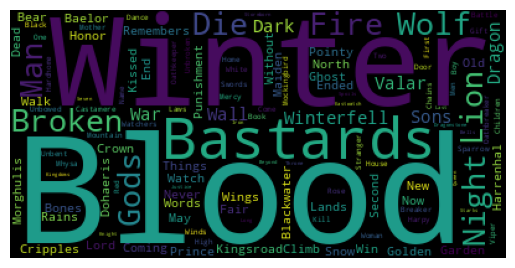

In [9]:
# Display word cloud
plt.imshow(word_cloud_1a)
plt.axis("off")
plt.show()

In [10]:
# Generate word cloud
word_cloud_1b = WordCloud(background_color='salmon', max_words=50,
                          random_state=42).generate(titles)

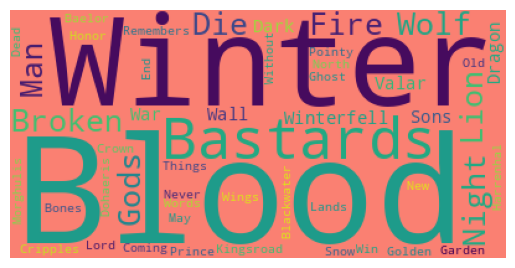

In [11]:
# Display word cloud
plt.imshow(word_cloud_1b)
plt.axis("off")
plt.show()

## Example 2

In [12]:
wiki = wikipedia.page("Barack Obama")

In [13]:
print(wiki.title)
print(wiki.url)
print(wiki.content)

Barack Obama
https://en.wikipedia.org/wiki/Barack_Obama
Barack Hussein Obama II (born August 4, 1961) is an American politician and lawyer who served as the 44th president of the United States from 2009 to 2017. A member of the Democratic Party, he was the first African-American president in U.S. history. Obama previously served as a U.S. senator representing Illinois from 2005 to 2008 and as an Illinois state senator from 1997 to 2004.
Obama was born in Honolulu, Hawaii. He graduated from Columbia University in 1983 with a Bachelor of Arts degree in political science and later worked as a community organizer in Chicago. In 1988, Obama enrolled in Harvard Law School, where he was the first black president of the Harvard Law Review. He became a civil rights attorney and an academic, teaching constitutional law at the University of Chicago Law School from 1992 to 2004. In 1996, Obama was elected to represent the 13th district in the Illinois Senate, a position he held until 2004, when he

In [14]:
wiki_text = wiki.content

In [15]:
# Generate word cloud
word_cloud_2a = WordCloud(background_color='skyblue',
                          random_state=42).generate(wiki_text)

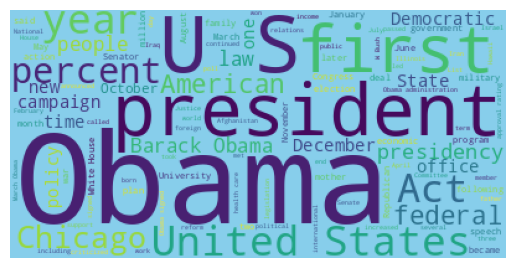

In [16]:
# Display word cloud
plt.imshow(word_cloud_2a)
plt.axis("off")
plt.show()

In [17]:
# Generate word cloud
word_cloud_2b = WordCloud(background_color='skyblue', max_words=50,
                          include_numbers=True, min_word_length=3,
                          random_state=42).generate(wiki_text)

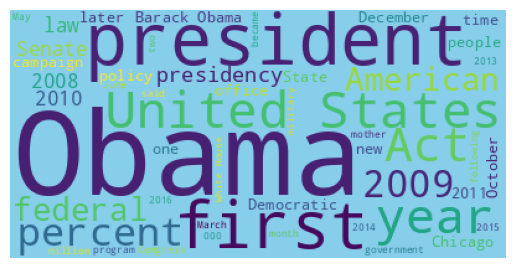

In [18]:
# Display word cloud
plt.imshow(word_cloud_2b)
plt.axis("off")
plt.show()